  SIAM — POPULATION DYNAMICS  (HEOM QuTiP)
  ε=-5.0, U=10.0, Γ* = U/π = 3.183
  Γ_list = [1.0, 1.5, 2.0, 3.18, 7.0, 10.0, 15.0]

  Γ=1.00  U/πΓ=3.18  [kondo]
10.0%. Run time:   0.23s. Est. time left: 00:00:00:02
20.0%. Run time:   0.44s. Est. time left: 00:00:00:01
30.1%. Run time:   0.65s. Est. time left: 00:00:00:01
40.1%. Run time:   0.87s. Est. time left: 00:00:00:01
50.1%. Run time:   1.08s. Est. time left: 00:00:00:01
60.1%. Run time:   1.29s. Est. time left: 00:00:00:00
70.1%. Run time:   1.51s. Est. time left: 00:00:00:00
80.2%. Run time:   1.74s. Est. time left: 00:00:00:00
90.2%. Run time:   1.96s. Est. time left: 00:00:00:00
100.0%. Run time:   2.17s. Est. time left: 00:00:00:00
Total run time:   2.18s
    HEOM solve: 2.30s

  Γ=1.50  U/πΓ=2.12  [kondo]
10.0%. Run time:   0.22s. Est. time left: 00:00:00:02
20.0%. Run time:   0.44s. Est. time left: 00:00:00:01
30.1%. Run time:   0.66s. Est. time left: 00:00:00:01
40.1%. Run time:   0.87s. Est. time left: 00:00:00:01
50.1%. Ru

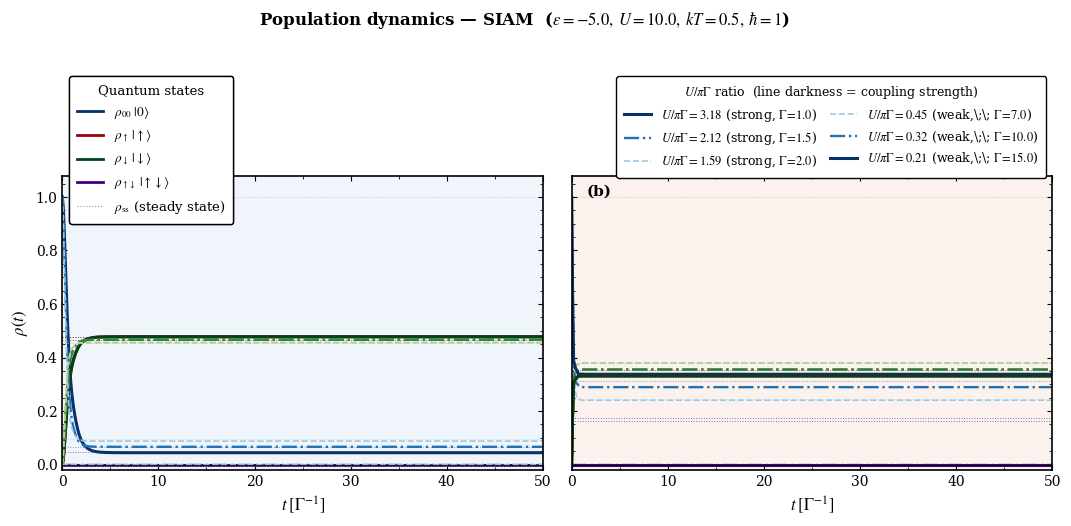


RÉSUMÉ DES ÉTATS STATIONNAIRES
  Gamma= 1.00  U/piGamma=3.183  [kondo ]  rho_ss=[empty=0.046, up=0.478, dn=0.478, double=-0.002]
  Gamma= 1.50  U/piGamma=2.122  [kondo ]  rho_ss=[empty=0.067, up=0.467, dn=0.467, double=-0.001]
  Gamma= 2.00  U/piGamma=1.592  [kondo ]  rho_ss=[empty=0.095, up=0.456, dn=0.456, double=-0.007]
  Gamma= 7.00  U/piGamma=0.455  [metal ]  rho_ss=[empty=0.244, up=0.380, dn=0.380, double=-0.004]
  Gamma=10.00  U/piGamma=0.318  [metal ]  rho_ss=[empty=0.314, up=0.355, dn=0.355, double=-0.025]
  Gamma=15.00  U/piGamma=0.212  [metal ]  rho_ss=[empty=0.162, up=0.331, dn=0.331, double=0.175]


In [8]:
"""
Évolution temporelle des populations — Modèle d'Anderson à une impureté (SIAM)
Méthode : QuTiP 5.x HEOM (LorentzianEnvironment + HEOMSolver)

Figure 1 — Grille 3×3 :
  • Une colonne par régime (fort / frontière / faible)
  • Une ligne par état (|0⟩, |↑⟩/|↓⟩, |↑↓⟩)
  • Chaque courbe colorée selon U/πΓ, style de trait selon le régime

Figure 2 — Grille 2×3 (une case par Γ + légende) :
  • Style identique au code Julia populations_2x3.jl
  • Toutes les populations sur le même axe, distinguées par couleur

Convention visuelle (identique DOS) :
  • Fort couplage  (U/πΓ > 1) : tirets --,  bleus froids
  • Frontière      (U/πΓ ≈ 1) : plein épais, gris foncé
  • Faible couplage(U/πΓ < 1) : plein fin,   oranges/rouges
"""

import contextlib
import dataclasses
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
from qutip import *
from qutip.core.environment import LorentzianEnvironment
from qutip.solver.heom import HEOMSolver
import warnings
warnings.filterwarnings("ignore")

# ── Style global publication ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"       : "serif",
    "mathtext.fontset"  : "stix",
    "font.size"         : 11,
    "axes.labelsize"    : 12,
    "axes.titlesize"    : 11,
    "axes.titleweight"  : "bold",
    "axes.linewidth"    : 1.2,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.top"         : True,
    "ytick.right"       : True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon"    : True,
    "legend.framealpha" : 1.0,
    "legend.edgecolor"  : "black",
})

# ── Palettes de régime (identiques au code DOS) ───────────────────────────────
KONDO_COLORS   = ["#2166AC", "#4393C3", "#92C5DE"]   # Γ = 1.0, 1.5, 2.0
BOUNDARY_COLOR = "#222222"                            # Γ = 3.18
METAL_COLORS   = ["#F4A582", "#D6604D", "#B2182B"]   # Γ = 7.0, 10.0, 15.0

# Couleurs des états quantiques (par population)
STATE_COLORS  = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
STATE_LABELS  = [r"$\rho_{00}\;|0\rangle$",
                 r"$\rho_{\uparrow}\;|\uparrow\rangle$",
                 r"$\rho_{\downarrow}\;|\downarrow\rangle$",
                 r"$\rho_{\uparrow\downarrow}\;|\uparrow\downarrow\rangle$"]
STATE_LSTYLES = ["-", "-", "-", "--"]

U_GLOBAL = 10.0
GAMMA_LIST   = [1.0, 1.5, 2.0, 3.18, 7.0, 10.0, 15.0]
GAMMA_STAR   = U_GLOBAL / np.pi   # ≈ 3.18

def classify(Gamma):
    """Retourne (regime, color, linewidth, linestyle) selon U/πΓ."""
    ratio = U_GLOBAL / (np.pi * Gamma)
    if abs(ratio - 1.0) < 0.02:
        return "boundary", BOUNDARY_COLOR, 3.0, "-"
    elif ratio > 1.0:
        idx = min(range(3), key=lambda i: abs([1.0,1.5,2.0][i] - Gamma))
        return "kondo", KONDO_COLORS[idx], 1.8, "--"
    else:
        idx = min(range(3), key=lambda i: abs([7.0,10.0,15.0][i] - Gamma))
        return "metal", METAL_COLORS[idx], 1.4, "-"

# ── Utilitaires ───────────────────────────────────────────────────────────────
@contextlib.contextmanager
def timer(label):
    start = time.time()
    yield
    print(f"    {label}: {time.time()-start:.2f}s")

# ── Paramètres système ────────────────────────────────────────────────────────
@dataclasses.dataclass
class SystemParameters:
    e1: float = -5.0
    U:  float = 10.0
    Nbos: int = 2

    def __post_init__(self):
        d_up     = tensor(destroy(2), qeye(self.Nbos))
        d_dn     = tensor(-sigmaz(),  destroy(2))
        self.H   = (self.e1 * (d_up.dag()*d_up + d_dn.dag()*d_dn)
                    + self.U * (d_up.dag()*d_up * d_dn.dag()*d_dn))
        self.Q1  = d_up
        self.Q2  = d_dn
        self.Q   = d_up + d_dn

@dataclasses.dataclass
class LorentzianBathParameters:
    lead : str
    Q    : object
    gamma: float = 0.5
    W    : float = 10.0
    T    : float = 0.5
    theta: float = 0.0

    def __post_init__(self):
        assert self.lead in ("L", "R")
        self.beta = 1.0 / self.T
        self.mu   = self.theta/2.0 if self.lead == "L" else -self.theta/2.0

def create_projectors(Nbos=2):
    dims = [[2, Nbos], [2, Nbos]]
    projs = []
    for k in range(4):
        arr = np.zeros((4, 4));  arr[k, k] = 1.0
        projs.append(Qobj(arr, dims=dims))
    return projs   # [P_empty, P_up, P_dn, P_double]

def solve_heom(sys_p, gamma, tlist, Nk=5):
    bath = LorentzianBathParameters(Q=sys_p.Q, lead="L", gamma=gamma)
    env  = LorentzianEnvironment(bath.T, bath.mu, bath.gamma, bath.W)
    env_pade = env.approx_by_pade(Nk=Nk)
    options  = {"nsteps": 1500, "store_states": True,
                "rtol": 1e-10, "atol": 1e-10, "method": "vern9"}
    solver   = HEOMSolver(sys_p.H, (env_pade, bath.Q),
                          max_depth=2, options=options)
    rho_init = create_projectors(sys_p.Nbos)[0]   # état vide comme CI
    result   = solver.run(rho_init, tlist)
    try:
        rho_ss, _ = solver.steady_state()
    except Exception as e:
        print(f"    Warning steady_state: {e} → using final state")
        rho_ss = result.states[-1]
    return result, rho_ss

def extract_pops(result, projs):
    pops = []
    for P in projs:
        series = [float(np.real(expect(P, s))) for s in result.states]
        pops.append(np.array(series))
    return pops

# ── Calcul pour tous les Gamma ────────────────────────────────────────────────
sys_p  = SystemParameters()
tlist  = np.linspace(0, 50, 500)
projs  = create_projectors(sys_p.Nbos)

print("=" * 65)
print("  SIAM — POPULATION DYNAMICS  (HEOM QuTiP)")
print("=" * 65)
print(f"  ε={sys_p.e1}, U={sys_p.U}, Γ* = U/π = {GAMMA_STAR:.3f}")
print(f"  Γ_list = {GAMMA_LIST}")
print("=" * 65)

all_pops  = {}
all_ss    = {}

for Gamma in GAMMA_LIST:
    regime, col, lw, ls = classify(Gamma)
    ratio = U_GLOBAL / (np.pi * Gamma)
    print(f"\n  Γ={Gamma:.2f}  U/πΓ={ratio:.2f}  [{regime}]")
    with timer("HEOM solve"):
        result, rho_ss = solve_heom(sys_p, Gamma, tlist)
    all_pops[Gamma] = extract_pops(result, projs)
    all_ss[Gamma]   = [float(np.real(expect(P, rho_ss))) for P in projs]

print("\n✓ Calcul terminé.\n")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — 1 ligne × 2 colonnes : fort couplage | faible couplage
# Toutes les populations superposées, Gamma distingué par nuance de couleur
# ══════════════════════════════════════════════════════════════════════════════

REGIME_GROUPS = {
    "strong": [1.0, 1.5, 2.0],
    "weak"  : [7.0, 10.0, 15.0],
}

REGIME_META = {
    "strong": {
        "title"  : "",
        "bg"     : "#F0F5FB",
        "title_c": "#1a4a8a",
        "panel"  : "(a)",
    },
    "weak": {
        "title"  : "",
        "bg"     : "#FBF2EE",
        "title_c": "#8B1A1A",
        "panel"  : "(b)",
    },
}

# ── Couleurs par état : bien contrastées, lisibles sur fond clair ─────────────
# Chaque état a une FAMILLE de 3 nuances (une par Gamma)
# Famille par état :
#   rho_00  : bleus profonds    (vide)
#   rho_up  : rouges/orangés    (spin up)
#   rho_dn  : verts             (spin down)
#   rho_ud  : violets           (doublement occupé)

STATE_FAMILIES = {
    # (rho_00, rho_up, rho_dn, rho_ud) pour chaque nuance claire → foncée
    "strong": [
        # Gamma=1.0 (dominant : couleurs foncées)
        {"rho_00": "#08306B", "rho_up": "#99000D", "rho_dn": "#00441B", "rho_ud": "#3F007D"},
        # Gamma=1.5 (intermédiaire)
        {"rho_00": "#2171B5", "rho_up": "#EF3B2C", "rho_dn": "#238B45", "rho_ud": "#6A51A3"},
        # Gamma=2.0 (secondaire : couleurs claires)
        {"rho_00": "#9ECAE1", "rho_up": "#FCBBA1", "rho_dn": "#A1D99B", "rho_ud": "#BCBDDC"},
    ],
    "weak": [
        # Gamma=7.0 (secondaire)
        {"rho_00": "#9ECAE1", "rho_up": "#FCBBA1", "rho_dn": "#A1D99B", "rho_ud": "#BCBDDC"},
        # Gamma=10.0 (intermédiaire)
        {"rho_00": "#2171B5", "rho_up": "#EF3B2C", "rho_dn": "#238B45", "rho_ud": "#6A51A3"},
        # Gamma=15.0 (dominant : couleurs foncées)
        {"rho_00": "#08306B", "rho_up": "#99000D", "rho_dn": "#00441B", "rho_ud": "#3F007D"},
    ],
}

LW_MAP = {
    "strong": [2.2, 1.7, 1.2],   # Gamma 1.0, 1.5, 2.0
    "weak"  : [1.2, 1.7, 2.2],   # Gamma 7.0, 10.0, 15.0
}
LS_MAP = {
    "strong": ["-", "-.", "--"],
    "weak"  : ["--", "-.", "-"],
}

STATE_KEYS   = ["rho_00", "rho_up", "rho_dn", "rho_ud"]
STATE_LABELS_LEGEND = [
    r"$\rho_{00}\;|0\rangle$",
    r"$\rho_{\uparrow}\;|\uparrow\rangle$",
    r"$\rho_{\downarrow}\;|\downarrow\rangle$",
    r"$\rho_{\uparrow\downarrow}\;|\uparrow\downarrow\rangle$",
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(11, 4.6), sharey=True,
    gridspec_kw={"wspace": 0.06,
                 "left": 0.08, "right": 0.98,
                 "bottom": 0.14, "top": 0.78}
)

for ax_idx, (regime_key, gammas) in enumerate(REGIME_GROUPS.items()):
    ax      = axes[ax_idx]
    meta    = REGIME_META[regime_key]
    colors  = STATE_FAMILIES[regime_key]
    lw_list = LW_MAP[regime_key]
    ls_list = LS_MAP[regime_key]

    ax.set_facecolor(meta["bg"])

    for g_idx, Gamma in enumerate(gammas):
        ratio    = U_GLOBAL / (np.pi * Gamma)
        col_set  = colors[g_idx]
        lw       = lw_list[g_idx]
        ls       = ls_list[g_idx]

        for si, sk in enumerate(STATE_KEYS):
            ax.plot(tlist, all_pops[Gamma][si],
                    color=col_set[sk], lw=lw, ls=ls)
            # État stationnaire : pointillé fin
            ax.axhline(all_ss[Gamma][si],
                       color=col_set[sk], lw=0.7, ls=":", alpha=0.6)

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax.set_xlim(tlist[0], tlist[-1])
    ax.set_ylim(-0.02, 1.08)
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline(1, color="black", lw=0.4, ls=":", alpha=0.3)
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.set_xlabel(r"$t \; [\Gamma^{-1}]$", fontsize=12)
    if ax_idx == 0:
        ax.set_ylabel(r"$\rho(t)$", fontsize=12)
    else:
        ax.tick_params(labelleft=False)

    ax.set_title(meta["title"], fontsize=11, fontweight="bold",
                 color=meta["title_c"], pad=7)
    ax.text(0.03, 0.97, meta["panel"],
            transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

# ══════════════════════════════════════════════════════════════════════════════
# LÉGENDE — deux blocs côte à côte au-dessus de la figure
#
#  Bloc gauche  : états quantiques (couleurs foncées = référence)
#  Bloc droit   : valeurs de Gamma (style de trait + nuance)
# ══════════════════════════════════════════════════════════════════════════════

# Bloc 1 — états (couleurs de référence = nuance foncée)
dark_ref = STATE_FAMILIES["strong"][0]   # nuances foncées
h_states = [
    mlines.Line2D([], [], color=dark_ref[sk], lw=2.0, ls="-", label=sl)
    for sk, sl in zip(STATE_KEYS, STATE_LABELS_LEGEND)
]
h_states.append(
    mlines.Line2D([], [], color="dimgray", lw=0.8, ls=":", alpha=0.7,
                  label=r"$\rho_{\rm ss}$ (steady state)"))

# Bloc 2 — Gamma : strong (foncé→clair = 1.0→2.0)
h_gamma = []
gamma_info = [
    # (label, lw, ls, nuance représentative)
    (r"$U/\pi\Gamma = 3.18$ (strong, $\Gamma\!=\!1.0$)", 2.2, "-",  "#08306B"),
    (r"$U/\pi\Gamma = 2.12$ (strong, $\Gamma\!=\!1.5$)", 1.7, "-.", "#2171B5"),
    (r"$U/\pi\Gamma = 1.59$ (strong, $\Gamma\!=\!2.0$)", 1.2, "--", "#9ECAE1"),
    (r"$U/\pi\Gamma = 0.45$ (weak,\;\; $\Gamma\!=\!7.0$)",  1.2, "--", "#9ECAE1"),
    (r"$U/\pi\Gamma = 0.32$ (weak,\;\; $\Gamma\!=\!10.0$)", 1.7, "-.", "#2171B5"),
    (r"$U/\pi\Gamma = 0.21$ (weak,\;\; $\Gamma\!=\!15.0$)", 2.2, "-",  "#08306B"),
]
for lbl, lw, ls, col in gamma_info:
    h_gamma.append(mlines.Line2D([], [], color=col, lw=lw, ls=ls, label=lbl))

# Légende états : en haut à gauche
leg1 = fig.legend(
    handles        = h_states,
    loc            = "upper left",
    bbox_to_anchor = (0.08, 1.01),
    ncol           = 1,
    fontsize       = 9.5,
    frameon        = True,
    edgecolor      = "black",
    title          = "Quantum states",
    title_fontsize = 9.5,
    handlelength   = 2.0,
    borderpad      = 0.6,
)

# Légende Gamma : en haut à droite
leg2 = fig.legend(
    handles        = h_gamma,
    loc            = "upper right",
    bbox_to_anchor = (0.98, 1.01),
    ncol           = 2,
    fontsize       = 9.0,
    frameon        = True,
    edgecolor      = "black",
    title          = r"$U/\pi\Gamma$ ratio  (line darkness = coupling strength)",
    title_fontsize = 9.0,
    handlelength   = 2.2,
    columnspacing  = 1.0,
    borderpad      = 0.6,
)

fig.add_artist(leg1)   # garder les deux légendes

fig.suptitle(
    rf"Population dynamics — SIAM"
    rf"  ($\varepsilon={sys_p.e1},\; U={sys_p.U},\; kT=0.5,\; \hbar=1$)",
    fontsize=12, fontweight="bold", y=1.14)

fig.savefig("populations_2regimes.pdf", bbox_inches="tight")
fig.savefig("populations_2regimes.png", dpi=300, bbox_inches="tight")
print("✓  Figure sauvegardée : populations_2regimes.pdf / .png")

plt.show()

# ── Résumé ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("RÉSUMÉ DES ÉTATS STATIONNAIRES")
print("=" * 65)
for Gamma in [1.0, 1.5, 2.0, 7.0, 10.0, 15.0]:
    regime, _, _, _ = classify(Gamma)
    ratio = U_GLOBAL / (np.pi * Gamma)
    ss    = all_ss[Gamma]
    print(f"  Gamma={Gamma:5.2f}  U/piGamma={ratio:.3f}  [{regime:6s}]  "
          f"rho_ss=[empty={ss[0]:.3f}, up={ss[1]:.3f}, "
          f"dn={ss[2]:.3f}, double={ss[3]:.3f}]")